# Topic Diversity using IRBO (Inverted Rank-Biased Overlap)

This notebook calculates topic diversity using **IRBO**, which is more robust than simple unique word ratio (TD) because:
- It considers **word ranking** (top words matter more than lower-ranked words)
- It's less sensitive to **number of topics**
- It's the standard metric used in **OCTIS** benchmark

**Analysis includes:**
- **Mean IRBO**: Average pairwise diversity (higher = more diverse)
- **Min IRBO**: The most similar topic pair — reveals hidden redundancy
- **Distribution Histogram**: Shows the spread of pairwise IRBO scores
- **Top-K Most Similar Pairs**: The actual topic words of the most similar pairs

**Reference:** Bianchi et al. (2021) - *"Pre-training is a Hot Topic: Contextualized Document Embeddings Improve Topic Coherence"*

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations
from bertopic import BERTopic
import matplotlib.pyplot as plt
import warnings
import gc

pd.set_option('display.max_colwidth', None)
warnings.filterwarnings("ignore", category=SyntaxWarning)

In [2]:
VERSION = "v1"
LIST_SUBJECT = ["cs", "math", "physics"]

TRANSFORMERS = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "all-distilroberta-v1",
    "intfloat/e5-base-v2",
    "all-mpnet-base-v2",
    "BAAI/bge-base-en-v1.5",
    "allenai/specter2"
]
DATA = "./data"
RESULT_DIR = Path(".")
TOP_N_WORDS = 10
RBO_P = 0.9
MIN_TOPIC_THRESHOLD = 100  
TOP_K_SIMILAR = 5

In [ ]:
def get_model_safe_name(model_name: str) -> str:
    return model_name.replace("/", "_").replace("-", "_")


def get_topic_words(topic_model: BERTopic, top_n: int = 10):
    """Extract top-N words for each topic (excluding topic -1), preserving rank order."""
    topics_words = []
    topic_ids = []
    for topic_id in topic_model.get_topics():
        if topic_id == -1:
            continue
        words = [word for word, _ in topic_model.get_topic(topic_id)[:top_n]]
        topics_words.append(words)
        topic_ids.append(topic_id)
    return topics_words, topic_ids


def rbo(list1, list2, p=0.9):
    if not list1 and not list2:
        return 1.0
    if not list1 or not list2:
        return 0.0

    # assign short (S) and long (L)
    if len(list1) <= len(list2):
        S, L = list1, list2
    else:
        S, L = list2, list1

    s, l = len(S), len(L)

    S_seen = set()
    L_seen = set()

    X = 0  # overlap
    rbo = 0.0
    disjoint = 0.0
    ext_term = 0.0

    for d in range(l):
        if d < s:
            s_item = S[d]
            S_seen.add(s_item)
        else:
            s_item = None

        l_item = L[d]
        L_seen.add(l_item)

        overlap_incr = 0

        if d < s:
            if s_item == l_item:
                overlap_incr = 1
            else:
                if s_item in L_seen:
                    overlap_incr += 1
                if l_item in S_seen:
                    overlap_incr += 1
        else:
            if l_item in S_seen:
                overlap_incr = 1

        X += overlap_incr

        if d < s:
            A_d = 2.0 * X / (len(S_seen) + len(L_seen))
        else:
            A_d = X / (d + 1)

        rbo += (1 - p) * (p ** d) * A_d

        if d < s:
            ext_term = A_d * (p ** (d + 1))
        else:
            X_s = X - overlap_incr if d == s else X_s
            disjoint += (1 - p) * (p ** d) * (
                X_s * (d + 1 - s) / ((d + 1) * s)
            )
            ext_term = (
                ((X - X_s) / (d + 1) + X_s / s)
                * (p ** (d + 1))
            )

        # optional optimization (safe)
        if p ** d < 1e-12:
            break

    return min(max(rbo + disjoint + ext_term, 0.0), 1.0)

def calculate_irbo_detailed(topics_words, topic_ids, p=0.9):
    """
    Calculate pairwise IRBO and return detailed results.
    Returns: mean_irbo, min_irbo, all pairwise scores with topic pair info.
    """
    if len(topics_words) < 2:
        return 0.0, 0.0, []
    
    pairwise_results = []
    for (i, j) in combinations(range(len(topics_words)), 2):
        similarity = rbo(topics_words[i], topics_words[j], p=p)
        irbo = 1.0 - similarity
        pairwise_results.append({
            'topic_i': topic_ids[i],
            'topic_j': topic_ids[j],
            'idx_i': i,
            'idx_j': j,
            'rbo': similarity,
            'irbo': irbo
        })
    
    irbo_scores = [r['irbo'] for r in pairwise_results]
    mean_irbo = np.mean(irbo_scores)
    min_irbo = np.min(irbo_scores)
    
    return mean_irbo, min_irbo, pairwise_results

## Calculate IRBO Diversity with Detailed Analysis

For each model: compute IRBO, find most similar pairs, and show distribution.

In [4]:
diversity_results = []
all_pairwise = {}  # store for histogram plotting

for subject in LIST_SUBJECT:
    print(f"\n{'='*80}")
    print(f"Subject: {subject.upper()}")
    print(f"{'='*80}")
    
    for model_name in TRANSFORMERS:
        model_safe_name = get_model_safe_name(model_name)
        model_path = str(RESULT_DIR / subject / f"{model_safe_name}_{VERSION}")
        
        print(f"\n[{model_name}]")
        
        if not os.path.exists(model_path):
            print(f"  ✗ Model not found")
            continue
        
        try:
            topic_model = BERTopic.load(model_path)
            n_topics = len(topic_model.get_topic_info()) - 1
            
            if n_topics < MIN_TOPIC_THRESHOLD:
                print(f"  ⚠ Excluded ({n_topics} topics < {MIN_TOPIC_THRESHOLD})")
                del topic_model
                gc.collect()
                continue
            
            topics_words, topic_ids = get_topic_words(topic_model, top_n=TOP_N_WORDS)
            print(f"  Topics: {n_topics} | Words per topic: {TOP_N_WORDS}")
            
            # Calculate detailed IRBO
            mean_irbo, min_irbo, pairwise = calculate_irbo_detailed(topics_words, topic_ids, p=RBO_P)
            
            key = (subject, model_name)
            all_pairwise[key] = {
                'pairwise': pairwise,
                'topics_words': topics_words,
                'topic_ids': topic_ids
            }
            
            # Summary stats
            irbo_scores = [r['irbo'] for r in pairwise]
            print(f"  IRBO Mean:   {mean_irbo:.6f}")
            print(f"  IRBO Min:    {min_irbo:.6f}  ← most similar pair")
            print(f"  IRBO Median: {np.median(irbo_scores):.6f}")
            print(f"  IRBO Std:    {np.std(irbo_scores):.6f}")
            print(f"  Percentage of perfect diversity: {sum(i == 1 for i in irbo_scores) / len(irbo_scores):.6f}")
            
            sorted_pairs = sorted(pairwise, key=lambda x: x['irbo'])
            print(f"\n  Top-{TOP_K_SIMILAR} Most Similar Topic Pairs (lowest IRBO = most similar):")
            print(f"  {'─'*75}")
            for rank, pair in enumerate(sorted_pairs[:TOP_K_SIMILAR], 1):
                ti, tj = pair['topic_i'], pair['topic_j']
                words_i = topics_words[pair['idx_i']][:10]
                words_j = topics_words[pair['idx_j']][:10]
                overlap = set(words_i) & set(words_j)
                print(f"  #{rank}. Topic {ti} vs Topic {tj}  |  IRBO: {pair['irbo']:.4f}  |  RBO: {pair['rbo']:.4f}")
                print(f"      Topic {ti}: {', '.join(words_i)}")
                print(f"      Topic {tj}: {', '.join(words_j)}")
                if overlap:
                    print(f"      Shared:    {', '.join(overlap)}")
                print()

                   
            diversity_results.append({
                "subject": subject,
                "model": model_name,
                "n_topics": n_topics,
                "irbo_mean": mean_irbo,
                "irbo_min": min_irbo,
                "irbo_median": np.median(irbo_scores),
                "irbo_std": np.std(irbo_scores),
                "n_pairs": len(pairwise)
            })
            
            del topic_model
            gc.collect()
            
        except Exception as e:
            print(f"  ✗ Error: {e}")

print(f"\n{'='*80}")
print("IRBO calculation complete!")
print(f"{'='*80}")


Subject: CS

[sentence-transformers/all-MiniLM-L6-v2]
  Topics: 180 | Words per topic: 10
  IRBO Mean:   0.996915
  IRBO Min:    0.573805  ← most similar pair
  IRBO Median: 1.000000
  IRBO Std:    0.018509
  Percentage of perfect diversity: 0.927809

  Top-5 Most Similar Topic Pairs (lowest IRBO = most similar):
  ───────────────────────────────────────────────────────────────────────────
  #1. Topic 65 vs Topic 77  |  IRBO: 0.5738  |  RBO: 0.4262
      Topic 65: quantum, classical, circuits, circuit, qubit, qubits, computing, computers, gates, algorithm
      Topic 77: quantum, classical, machine, qml, learning, circuits, neural, circuit, qubit, qnns
      Shared:    qubit, quantum, circuit, circuits, classical

  #2. Topic 65 vs Topic 135  |  IRBO: 0.6292  |  RBO: 0.3708
      Topic 65: quantum, classical, circuits, circuit, qubit, qubits, computing, computers, gates, algorithm
      Topic 135: quantum, classical, entanglement, channel, states, channels, communication, capacity, en

## IRBO Distribution Histograms

Histogram of pairwise IRBO scores per model per subject.  
If most values are clustered at ~1.0 but there's a **tail to the left**, that means some topic pairs are suspiciously similar.

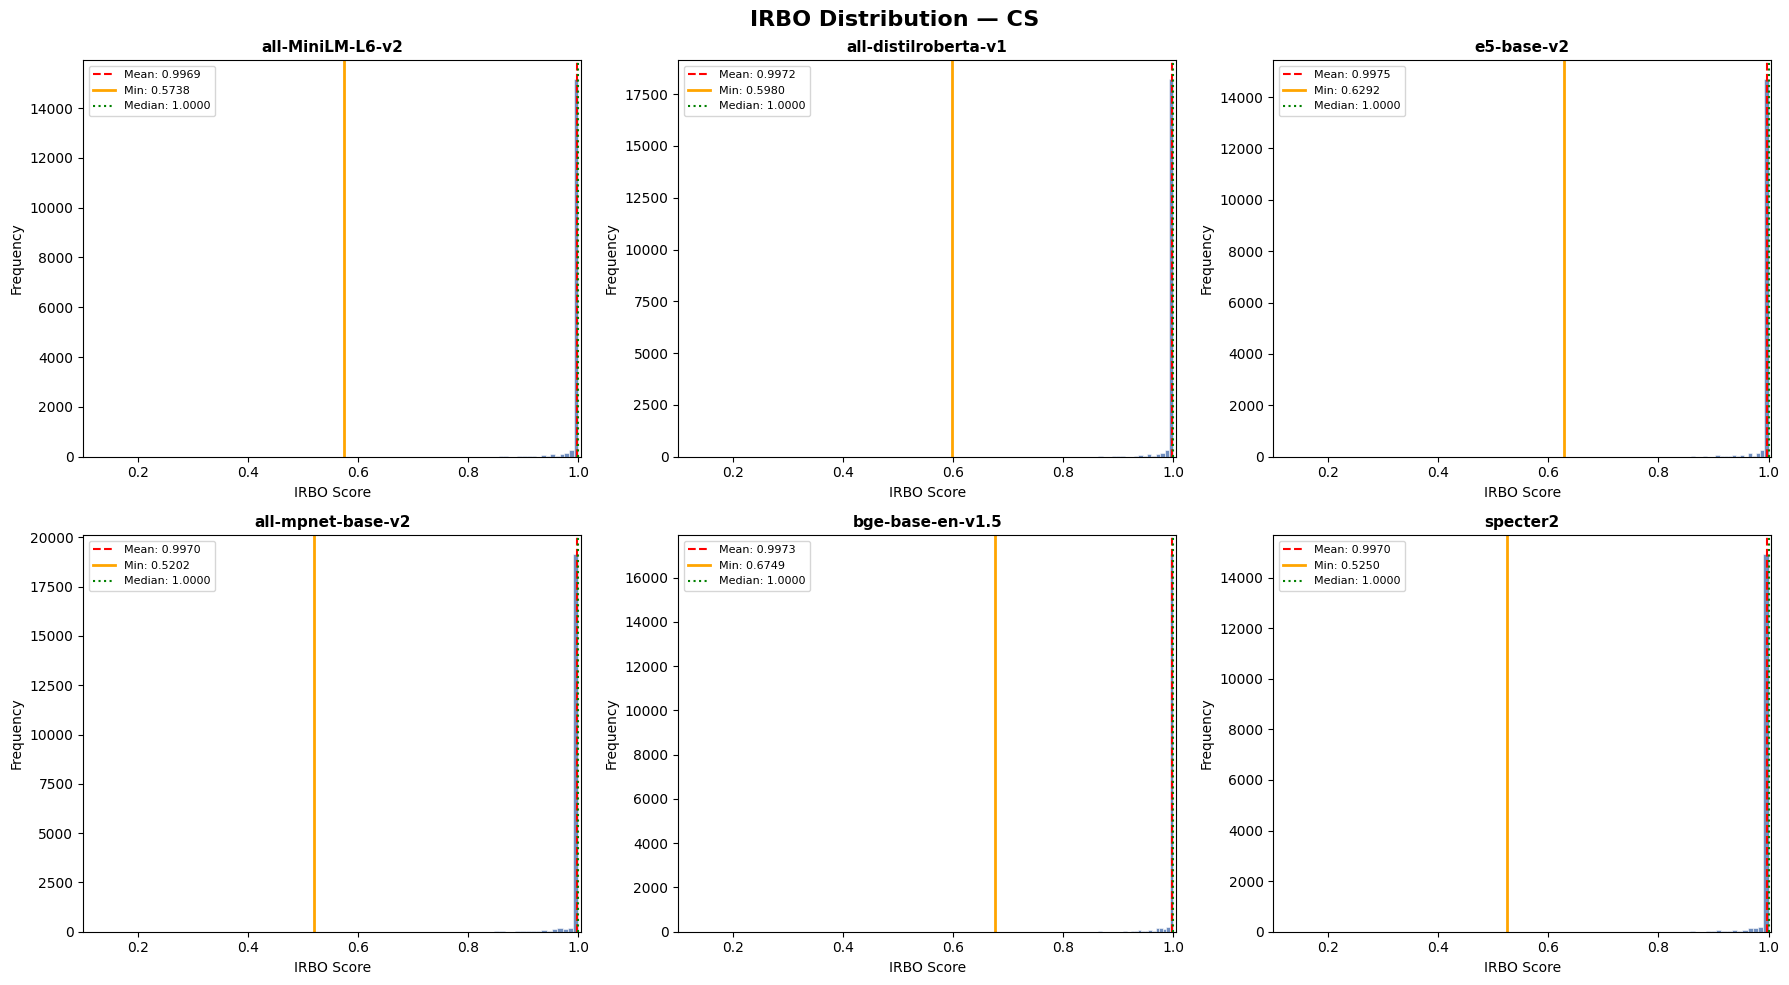

Saved: irbo_distribution_cs_v1.png



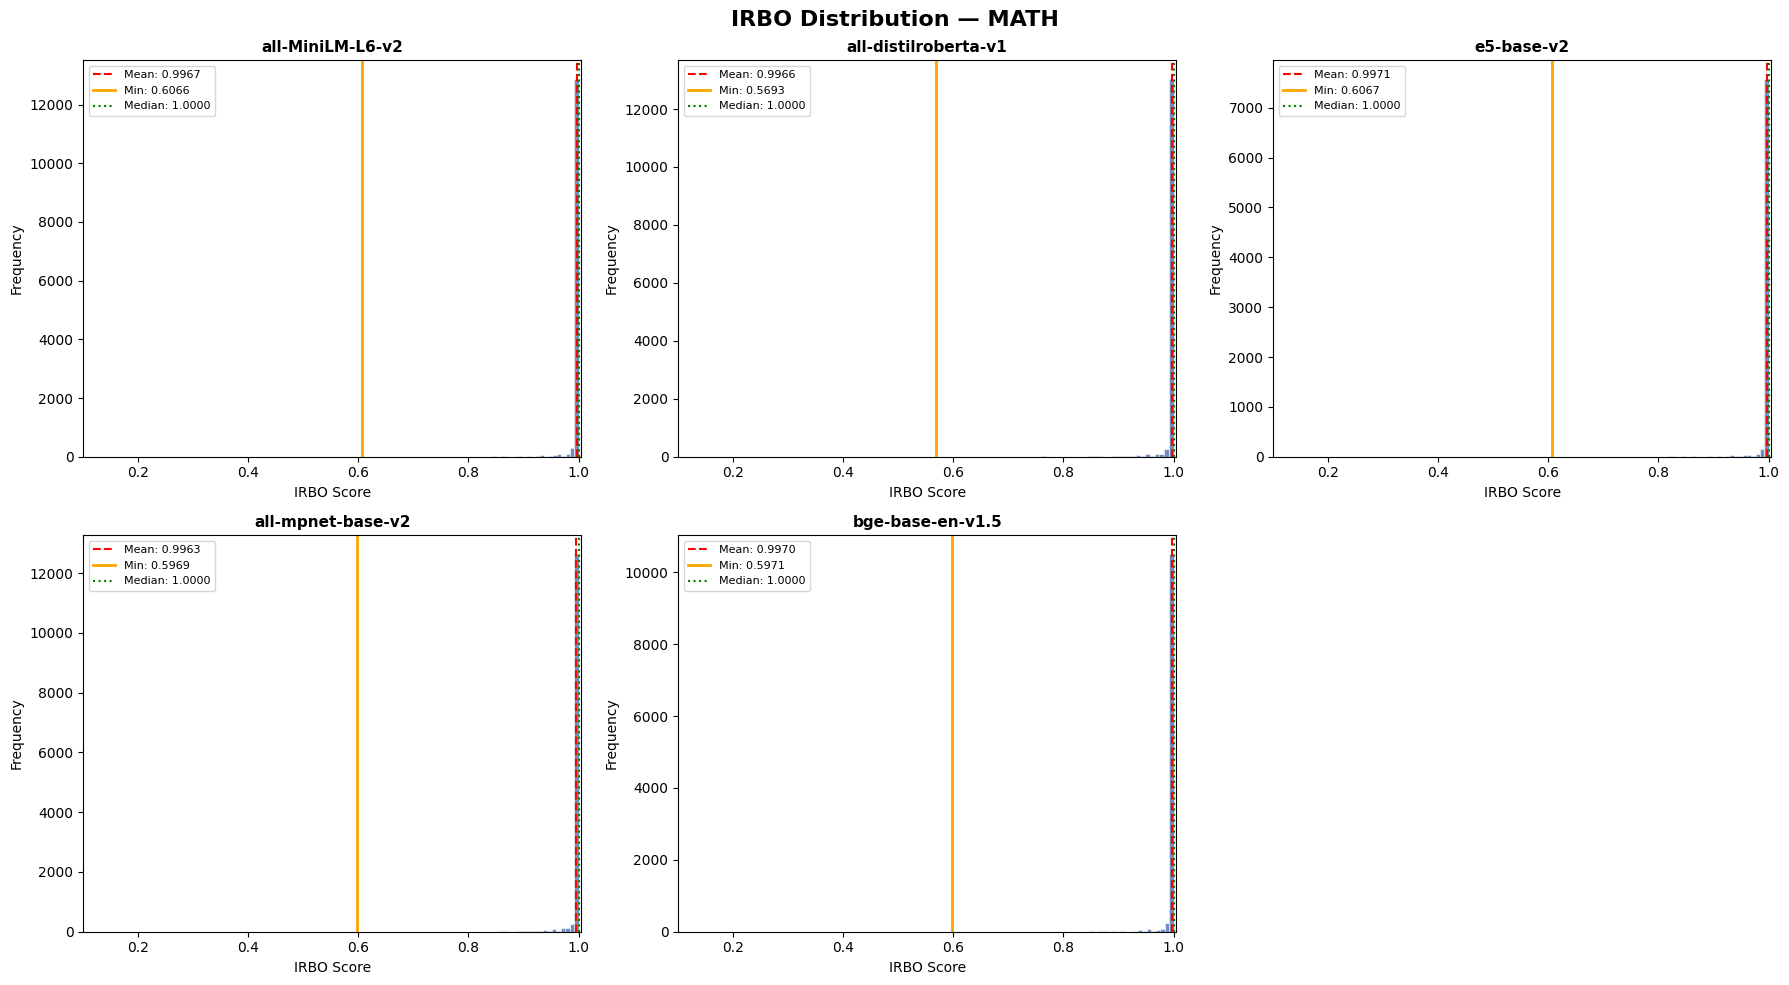

Saved: irbo_distribution_math_v1.png



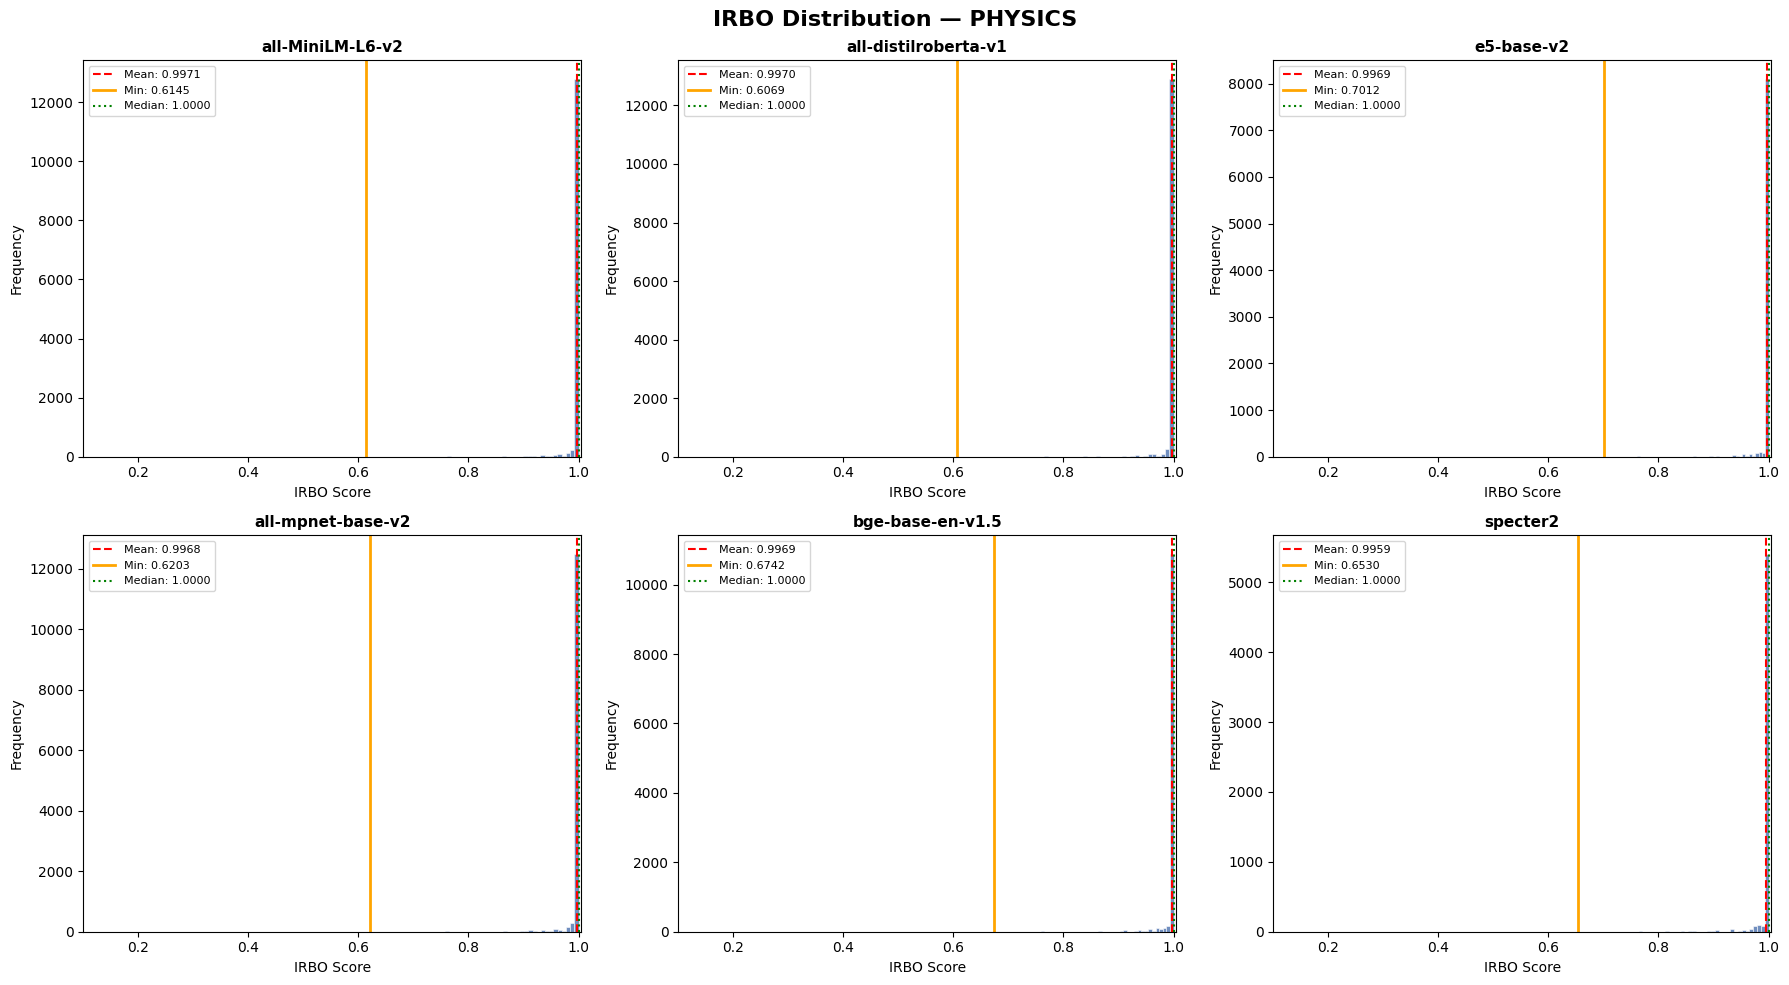

Saved: irbo_distribution_physics_v1.png



In [5]:
for subject in LIST_SUBJECT:
    # Collect models that have data for this subject
    models_with_data = [(m, all_pairwise[(subject, m)]) 
                        for m in TRANSFORMERS 
                        if (subject, m) in all_pairwise]
    
    if not models_with_data:
        continue
    
    n_models = len(models_with_data)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'IRBO Distribution — {subject.upper()}', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    for idx, (model_name, data) in enumerate(models_with_data):
        ax = axes[idx]
        irbo_scores = [r['irbo'] for r in data['pairwise']]
        
        # Histogram
        ax.hist(irbo_scores, bins=50, color='#4C72B0', alpha=0.8, edgecolor='white', linewidth=0.5)
        
        # Stats lines
        mean_val = np.mean(irbo_scores)
        min_val = np.min(irbo_scores)
        median_val = np.median(irbo_scores)
        
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.4f}')
        ax.axvline(min_val, color='orange', linestyle='-', linewidth=2, label=f'Min: {min_val:.4f}')
        ax.axvline(median_val, color='green', linestyle=':', linewidth=1.5, label=f'Median: {median_val:.4f}')
        
        # Formatting
        short_name = model_name.split('/')[-1] if '/' in model_name else model_name
        ax.set_title(f'{short_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('IRBO Score')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8, loc='upper left')
        ax.set_xlim(0.1, 1.005)
    
    # Hide unused axes
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    # plt.savefig(RESULT_DIR / f'irbo_distribution_{subject}_{VERSION}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: irbo_distribution_{subject}_{VERSION}.png\n")

### Zoomed-In: Low IRBO Tail

Focus on the **lower tail** of the distribution to see outlier similar pairs more clearly.

## Summary Table

All IRBO stats at a glance — **Min IRBO** reveals the worst-case topic similarity.

In [6]:
diversity_df = pd.DataFrame(diversity_results)
diversity_csv_path = RESULT_DIR / "data" / f"diversity_irbo_results_{VERSION}.csv"
diversity_df.to_csv(diversity_csv_path, index=False)

print("\nIRBO Diversity Summary:")
print("=" * 120)
print(f"{'Subject':<10} {'Model':<45} {'#Topics':>7} {'Mean':>8} {'Min':>8} {'Median':>8} {'Std':>8} {'#Pairs':>8}")
print("-" * 120)
for _, row in diversity_df.iterrows():
    print(
        f"{row['subject']:<10} "
        f"{row['model']:<45} "
        f"{int(row['n_topics']):>7} "
        f"{row['irbo_mean']:>8.4f} "
        f"{row['irbo_min']:>8.4f} "
        f"{row['irbo_median']:>8.4f} "
        f"{row['irbo_std']:>8.4f} "
        f"{int(row['n_pairs']):>8}"
    )
print("=" * 120)
print(f"\nSaved to: {diversity_csv_path}")


IRBO Diversity Summary:
Subject    Model                                         #Topics     Mean      Min   Median      Std   #Pairs
------------------------------------------------------------------------------------------------------------------------
cs         sentence-transformers/all-MiniLM-L6-v2            180   0.9969   0.5738   1.0000   0.0185    16110
cs         all-distilroberta-v1                              197   0.9972   0.5980   1.0000   0.0170    19306
cs         intfloat/e5-base-v2                               177   0.9975   0.6292   1.0000   0.0149    15576
cs         all-mpnet-base-v2                                 201   0.9970   0.5202   1.0000   0.0181    20100
cs         BAAI/bge-base-en-v1.5                             191   0.9973   0.6749   1.0000   0.0156    18145
cs         allenai/specter2                                  178   0.9970   0.5250   1.0000   0.0177    15753
math       sentence-transformers/all-MiniLM-L6-v2            166   0.9967   0.6066  

## Combine IRBO with Coherence

Compute **Topic Quality** as the harmonic mean of Coherence and IRBO:

$$\text{Topic Quality} = 2 \times \frac{\text{Coherence} \times \text{IRBO}}{\text{Coherence} + \text{IRBO}}$$

In [7]:
# Load coherence results
coherence_df = pd.read_csv(RESULT_DIR / DATA/ f"coherence_results_{VERSION}.csv")
print(f"Coherence results: {len(coherence_df)} rows")

# Load IRBO diversity results
diversity_df = pd.read_csv(RESULT_DIR / DATA/ f"diversity_irbo_results_{VERSION}.csv")
print(f"Diversity results: {len(diversity_df)} rows")

# Merge
combined_df = coherence_df.merge(
    diversity_df[['subject', 'model', 'n_topics', 'irbo_mean', 'irbo_min']],
    on=['subject', 'model'],
    how='inner'
)

# Rename for backward compat
combined_df['irbo'] = combined_df['irbo_mean']

# Topic Quality = harmonic mean of coherence and IRBO
combined_df['topic_quality'] = (
    2 * combined_df['coherence'] * combined_df['irbo'] /
    (combined_df['coherence'] + combined_df['irbo'])
)


# Save
combined_csv_path = RESULT_DIR / DATA / f"topic_quality_irbo_results_{VERSION}.csv"
combined_df.to_csv(combined_csv_path, index=False)

print(f"\nCombined results: {len(combined_df)} rows")
print(f"Saved to: {combined_csv_path}")

Coherence results: 18 rows
Diversity results: 17 rows

Combined results: 17 rows
Saved to: data/topic_quality_irbo_results_v1.csv


In [8]:
print("\n" + "=" * 120)
print("COMBINED TOPIC QUALITY RESULTS (using IRBO)")
print("=" * 120)
print(f"{'Subject':<10} {'Model':<45} {'Coherence':>9} {'IRBO':>8} {'Min IRBO':>9} {'Quality':>8}")
print("-" * 120)

for subject in LIST_SUBJECT:
    subject_data = combined_df[combined_df['subject'] == subject].sort_values('topic_quality', ascending=False)
    for _, row in subject_data.iterrows():
        print(
            f"{row['subject']:<10} "
            f"{row['model']:<45} "
            f"{row['coherence']:>9.4f} "
            f"{row['irbo']:>8.4f} "
            f"{row['irbo_min']:>9.4f} "
            f"{row['topic_quality']:>8.4f}"
        )
    print("-" * 120)

print("=" * 120)


COMBINED TOPIC QUALITY RESULTS (using IRBO)
Subject    Model                                         Coherence     IRBO  Min IRBO  Quality
------------------------------------------------------------------------------------------------------------------------
cs         all-distilroberta-v1                             0.7322   0.9972    0.5980   0.8444
cs         intfloat/e5-base-v2                              0.7242   0.9975    0.6292   0.8392
cs         allenai/specter2                                 0.7210   0.9970    0.5250   0.8368
cs         BAAI/bge-base-en-v1.5                            0.7198   0.9973    0.6749   0.8361
cs         sentence-transformers/all-MiniLM-L6-v2           0.7148   0.9969    0.5738   0.8326
cs         all-mpnet-base-v2                                0.7146   0.9970    0.5202   0.8325
------------------------------------------------------------------------------------------------------------------------
math       BAAI/bge-base-en-v1.5                

In [9]:
# --- BEST MODEL PER SUBJECT ---
print("\n" + "=" * 100)
print("BEST MODEL PER SUBJECT (by Topic Quality)")
print("=" * 100)

for subject in LIST_SUBJECT:
    subject_data = combined_df[combined_df['subject'] == subject]
    if len(subject_data) > 0 and subject_data['topic_quality'].notna().any():
        best = subject_data.loc[subject_data['topic_quality'].idxmax()]
        print(f"\n  {subject.upper()}:")
        print(f"    Model:      {best['model']}")
        print(f"    Coherence:  {best['coherence']:.4f}")
        print(f"    IRBO Mean:  {best['irbo']:.6f}")
        print(f"    IRBO Min:   {best['irbo_min']:.6f}")
        print(f"    Quality:    {best['topic_quality']:.4f}")
        print(f"    # Topics:   {int(best['n_topics_x'])}")

print("\n" + "=" * 100)

# --- OVERALL BEST ---
best_overall = combined_df.loc[combined_df['topic_quality'].idxmax()]
print(f"\n★ OVERALL BEST: {best_overall['model']} ({best_overall['subject']}) with Quality = {best_overall['topic_quality']:.4f}")
print(f"  (Coherence={best_overall['coherence']:.4f}, IRBO={best_overall['irbo']:.6f})")


BEST MODEL PER SUBJECT (by Topic Quality)

  CS:
    Model:      all-distilroberta-v1
    Coherence:  0.7322
    IRBO Mean:  0.997213
    IRBO Min:   0.598013
    Quality:    0.8444
    # Topics:   197

  MATH:
    Model:      BAAI/bge-base-en-v1.5
    Coherence:  0.7229
    IRBO Mean:  0.996968
    IRBO Min:   0.597098
    Quality:    0.8381
    # Topics:   150

  PHYSICS:
    Model:      all-distilroberta-v1
    Coherence:  0.7387
    IRBO Mean:  0.996997
    IRBO Min:   0.606939
    Quality:    0.8486
    # Topics:   166


★ OVERALL BEST: all-distilroberta-v1 (physics) with Quality = 0.8486
  (Coherence=0.7387, IRBO=0.996997)
